In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [153]:
bills_path = "../pull_open_states/intermediate_data/openstates_w_names.csv"
donations_path = "../pull_IL_sunshine/intermediate_data/donation_stats.csv"

In [154]:
bills_full = pd.read_csv(bills_path)
donations_stats = pd.read_csv(donations_path)

In [155]:
bills_full.head(3)

,Unnamed: 0,id,identifier,title,classification,subject,session_identifier,jurisdiction,organization_classification,abstract,...,num_sponsors,primary_sponsor_1,primary_sponsor_2,num_primary_sponsors,first_to_last_action_days,days_to_first_reading,days_to_first_committee_referral,days_to_first_committee_passage,abstract_action,primary_sponsor_1_clean
0,0,ocd-bill/f4c0d518-f592-4828-8c23-532ec44ed642,HB 1277,PEN CD-FELONY-SUSPEND BENEFITS,['bill'],[],103rd,Illinois,lower,Amends the General Provisions Article of the I...,...,5,Amy Elik,NaN,1,523,12.0,NaN,NaN,amends,Amy Elik
1,1,ocd-bill/ea6533c0-942f-4f92-aef7-bef03046387c,HB 4017,$DHS-INDEPENDENT LIVING CNTRS,['bill'],[],103rd,Illinois,lower,"Appropriates $16,358,900 from the General Reve...",...,6,Nabeela Syed,NaN,1,367,1.0,NaN,NaN,appropriates,Nabeela Syed
2,2,ocd-bill/0372f02d-3773-4ce5-9f26-26f0141e2227,SB 2535,YOUTH NON-VIOLENT RESOURCES,['bill'],[],103rd,Illinois,upper,Amends the Illinois Criminal Justice Informati...,...,12,"Elgie R. Sims, Jr.",NaN,1,423,0.0,323.0,NaN,amends,Elgie Sims Jr


In [156]:
df = bills_full.merge(donations_stats, how = "left", left_on = "primary_sponsor_1_clean", right_on = "name")

In [157]:
df.head()

,Unnamed: 0,id,identifier,title,classification,subject,session_identifier,jurisdiction,organization_classification,abstract,...,pct_$_allcond_all,pct_$_allcond_L3,amt_IL_all,amt_IL_L3,pct_c_IL_all,pct_c_IL_L3,pct_$_IL_all,pct_$_IL_L3,yrs_since_first,yrs_since_last
0,0,ocd-bill/f4c0d518-f592-4828-8c23-532ec44ed642,HB 1277,PEN CD-FELONY-SUSPEND BENEFITS,['bill'],[],103rd,Illinois,lower,Amends the General Provisions Article of the I...,...,0.184268,0.407513,1285846.90,283226.95,0.887513,0.840970,0.931944,0.834792,7.0,0.0
1,1,ocd-bill/ea6533c0-942f-4f92-aef7-bef03046387c,HB 4017,$DHS-INDEPENDENT LIVING CNTRS,['bill'],[],103rd,Illinois,lower,"Appropriates $16,358,900 from the General Reve...",...,0.171360,0.244505,3265006.71,1735720.73,0.883061,0.926056,0.936405,0.917839,5.0,0.0
2,2,ocd-bill/0372f02d-3773-4ce5-9f26-26f0141e2227,SB 2535,YOUTH NON-VIOLENT RESOURCES,['bill'],[],103rd,Illinois,upper,Amends the Illinois Criminal Justice Informati...,...,0.131252,0.033628,2357769.80,785269.34,0.775717,0.787625,0.800433,0.810022,17.0,0.0
3,3,ocd-bill/b3f19d64-64ee-4061-94be-294fd4d5b6ca,SB 2816,ORGANIC WASTE COMPOSTING,['bill'],[],103rd,Illinois,upper,Amends the Environmental Protection Act. Requi...,...,0.407186,0.383038,571184.04,374956.91,0.855191,0.828125,0.862835,0.877487,6.0,0.0
4,4,ocd-bill/4ae56f70-b57b-4d05-a6ef-d22839d5fee1,HB 3418,REENTRY INTO THE WORKFORCE,['bill'],[],103rd,Illinois,lower,Creates the Securing All Futures through Equit...,...,0.375334,0.387853,1443310.39,588275.82,0.802960,0.807882,0.863167,0.872650,9.0,1.0


In [158]:
df.columns

Index(['Unnamed: 0', 'id', 'identifier', 'title', 'classification', 'subject',
       'session_identifier', 'jurisdiction', 'organization_classification',
       'abstract', 'note', 'bill_id', 'first_action', 'last_action',
       'num_actions', 'amendment_introductions', 'num_readings',
       'committee_passages', 'passed_first_chamber', 'passed_full_legislature',
       'became_law', 'vetoed', 'first_reading_date',
       'first_committee_referral_date', 'first_committee_passage_date',
       'num_sponsors', 'primary_sponsor_1', 'primary_sponsor_2',
       'num_primary_sponsors', 'first_to_last_action_days',
       'days_to_first_reading', 'days_to_first_committee_referral',
       'days_to_first_committee_passage', 'abstract_action',
       'primary_sponsor_1_clean', 'name', 'donation_count_all',
       'donation_count_L3', 'total_all', 'total_L3', 'pct_c_above_all',
       'pct_c_above_L3', 'pct_$_above_all', 'pct_$_above_L3',
       'avg_donation_all', 'avg_donation_L3', 'amt_non

In [159]:
# Covert date columns to datetime for analysis
df["first_action"] = pd.to_datetime(df["first_action"])
df["last_action"] = pd.to_datetime(df["last_action"])
df["first_reading_date"] = pd.to_datetime(df["first_reading_date"])
df["first_committee_referral_date"]	= pd.to_datetime(df["first_committee_referral_date"])
df["first_committee_passage_date"] = pd.to_datetime(df["first_committee_passage_date"])

In [160]:
df["passed_full_legislature"] = df["passed_full_legislature"].astype(int)

## Correlations

In [161]:
correlations = df.corr(numeric_only=True)["passed_full_legislature"]

sorted_corrs = correlations.sort_values(ascending = False)
sorted_corrs = sorted_corrs.drop(["passed_full_legislature", "passed_first_chamber", "became_law"])

In [162]:
sorted_corrs

num_primary_sponsors                0.841228
num_readings                        0.811749
num_actions                         0.741627
committee_passages                  0.553090
amendment_introductions             0.531245
num_sponsors                        0.466453
days_to_first_committee_passage     0.121343
vetoed                              0.077699
pct_$_IL_all                        0.076460
pct_c_non1a_L3                      0.047033
pct_c_allcond_all                   0.044156
pct_c_non1a_all                     0.044106
pct_c_nofirst_L3                    0.032847
pct_c_allcond_L3                    0.032768
pct_c_nofirst_all                   0.026485
pct_$_nofirst_all                   0.023025
pct_$_non1a_all                     0.021031
pct_c_IL_all                        0.011304
pct_c_entity_L3                     0.010047
pct_c_entity_all                    0.010031
yrs_since_last                      0.006560
pct_$_nofirst_L3                   -0.009939
pct_$_non1

## Looking at individual variables

In [163]:
df["passed_full_legislature"].mean() * 100

np.float64(11.038474973801089)

In [164]:
df.groupby("session_identifier")["passed_full_legislature"].agg(["mean", "count"])

,mean,count
session_identifier,,
102nd,0.113418,10113
103rd,0.107294,9926


In [165]:
df.groupby("organization_classification")["passed_full_legislature"].agg(["mean", "count"])

,mean,count
organization_classification,,
lower,0.101764,11792
upper,0.122711,8247


In [166]:
df.groupby("abstract_action")["passed_full_legislature"].agg(["mean", "count"]) 

,mean,count
abstract_action,,
amends,0.120790,16566
"amends,",0.000000,2
an,0.000000,5
appropriates,0.006903,1014
appropriations,0.000000,8
authorizes,0.275862,29
creates,0.116688,1534
directs,0.000000,2
establishes,1.000000,1


In [167]:
df.groupby("num_primary_sponsors")["passed_full_legislature"].agg(["mean", "count"])

,mean,count
num_primary_sponsors,,
1,0.001402,17114
2,0.748034,2925


In [168]:
df.groupby(pd.cut(df["num_sponsors"], [0,1,  2, 5, 10, 15, 20, 25, 150]))["passed_full_legislature"].agg(["mean", "count"])

,mean,count
num_sponsors,,
"(0, 1]",0.000000,13024
"(1, 2]",0.113327,2056
"(2, 5]",0.291998,1887
"(5, 10]",0.358773,1271
"(10, 15]",0.458781,558
"(15, 20]",0.495146,412
"(20, 25]",0.569106,246
"(25, 150]",0.635897,585


In [169]:
df.groupby(df["first_action"].dt.month)["passed_full_legislature"].agg(["mean", "count"]) 

,mean,count
first_action,,
1,0.134620,4405
2,0.114780,13173
3,0.009494,316
4,0.024194,124
5,0.025974,154
6,0.000000,24
7,0.051282,39
8,0.059701,67
9,0.027027,74


In [170]:
df.groupby("committee_passages")["passed_full_legislature"].agg(["mean", "count"]) 

,mean,count
committee_passages,,
0,0.043515,15236
1,0.109811,3333
2,0.778107,1014
3,0.885246,366
4,0.802817,71
5,0.785714,14
6,0.250000,4
7,1.000000,1


## % of Bills Hitting Milestones

In [171]:
passed = df["passed_full_legislature"] == 1

In [172]:
df["first_reading_date"].notna().mean()

np.float64(0.9998003892409801)

In [173]:
df[passed]["first_reading_date"].notna().mean()

np.float64(1.0)

In [174]:
df[~passed]["first_reading_date"].notna().mean()

np.float64(0.9997756212486677)

In [175]:
df["first_committee_referral_date"].notna().mean()

np.float64(0.8453016617595689)

In [176]:
df[passed]["first_committee_referral_date"].notna().mean()

np.float64(1.0)

In [177]:
df[~passed]["first_committee_referral_date"].notna().mean()

np.float64(0.8261064677175072)

In [178]:
df["first_committee_passage_date"].notna().mean()

np.float64(0.23968261889315834)

In [179]:
df[passed]["first_committee_passage_date"].notna().mean()

np.float64(0.7002712477396021)

In [180]:
df[~passed]["first_committee_passage_date"].notna().mean()

np.float64(0.18253211420878443)

In [181]:
df["passed_first_chamber"].mean()

np.float64(0.14766205898497928)

In [182]:
df[passed]["passed_first_chamber"].mean()

np.float64(1.0)

In [183]:
df[~passed]["passed_first_chamber"].mean()

np.float64(0.04190273181129747)

In [184]:
df["passed_full_legislature"].mean()

np.float64(0.11038474973801088)

In [185]:
df["became_law"].mean()

np.float64(0.1098857228404611)

## Timing By Bill Outcome

In [186]:
df.groupby("passed_full_legislature")["days_to_first_reading"].mean()

passed_full_legislature
0    4.700331
1    2.283454
Name: days_to_first_reading, dtype: float64

In [187]:
df.groupby("passed_full_legislature")["days_to_first_committee_referral"].mean()

passed_full_legislature
0    16.302234
1    12.111664
Name: days_to_first_committee_referral, dtype: float64

In [188]:
df.groupby("passed_full_legislature")["days_to_first_committee_passage"].mean()

passed_full_legislature
0    40.403503
1    58.022595
Name: days_to_first_committee_passage, dtype: float64

In [189]:
df.groupby("passed_full_legislature")["first_to_last_action_days"].mean()

passed_full_legislature
0    346.329949
1    201.505877
Name: first_to_last_action_days, dtype: float64

## Sponsors

In [190]:
sponsors = df.groupby("primary_sponsor_1_clean")["passed_full_legislature"].agg(["mean", "count"])

In [191]:
sponsors.shape

(223, 2)

In [192]:
sponsors.head(20)

,mean,count
primary_sponsor_1_clean,,
Aaron Ortiz,0.222222,36
Abdelnasser Rashid,0.148936,47
Adam Niemerg,0.058252,103
Adriane Johnson,0.370861,151
Amy Elik,0.166667,84
Amy Grant,0.000000,34
Andrew Chesney,0.109375,64
Angie Cuellar,0.348837,43
Ann Gillespie,0.538462,65


In [193]:
donations_stats.shape

(223, 43)

In [194]:
donations_stats["name"].sort_values().head(20)

159           Aaron Ortiz
132    Abdelnasser Rashid
66           Adam Niemerg
3         Adriane Johnson
0                Amy Elik
98              Amy Grant
86         Andrew Chesney
166         Angie Cuellar
180         Ann Gillespie
43           Ann Williams
65           Anna Moeller
131            Anne Stava
54         Anthony DeLuca
186         Antonio Munoz
192          Avery Bourne
162     Barbara Hernandez
87        Bill Cunningham
154           Bill Hauter
84         Blaine Wilhour
26             Bob Morgan
Name: name, dtype: str

In [195]:
df_sponsors = sponsors.merge(donations_stats, how = "inner", left_on = "primary_sponsor_1_clean", right_on = "name")

In [196]:
df_sponsors = df_sponsors.rename(columns={"mean": "passage_rate", "count": "num_bills_primary"})

In [197]:
df_sponsors.head(5)

,passage_rate,num_bills_primary,name,donation_count_all,donation_count_L3,total_all,total_L3,pct_c_above_all,pct_c_above_L3,pct_$_above_all,...,pct_$_allcond_all,pct_$_allcond_L3,amt_IL_all,amt_IL_L3,pct_c_IL_all,pct_c_IL_L3,pct_$_IL_all,pct_$_IL_L3,yrs_since_first,yrs_since_last
0,0.222222,36,Aaron Ortiz,834.0,241.0,1664104.54,850321.64,0.231415,0.311203,0.807101,...,0.377110,0.347422,1415141.10,650320.98,0.860911,0.763485,0.850392,0.764794,9.0,0.0
1,0.148936,47,Abdelnasser Rashid,1623.0,1135.0,1906920.53,1290674.34,0.174368,0.162115,0.725399,...,0.031947,0.040560,1743611.38,1159465.19,0.795441,0.750661,0.914360,0.898341,4.0,0.0
2,0.058252,103,Adam Niemerg,267.0,105.0,357025.82,151562.85,0.146067,0.180952,0.694490,...,0.125061,0.128330,339837.52,146196.60,0.883895,0.933333,0.951857,0.964594,7.0,1.0
3,0.370861,151,Adriane Johnson,732.0,448.0,661985.36,427307.57,0.121585,0.145089,0.501488,...,0.407186,0.383038,571184.04,374956.91,0.855191,0.828125,0.862835,0.877487,6.0,0.0
4,0.166667,84,Amy Elik,969.0,371.0,1379747.54,339278.27,0.154799,0.115903,0.728818,...,0.184268,0.407513,1285846.90,283226.95,0.887513,0.840970,0.931944,0.834792,7.0,0.0


In [198]:
df_sponsors.sort_values(by="passage_rate", ascending=False).head(10)

,passage_rate,num_bills_primary,name,donation_count_all,donation_count_L3,total_all,total_L3,pct_c_above_all,pct_c_above_L3,pct_$_above_all,...,pct_$_allcond_all,pct_$_allcond_L3,amt_IL_all,amt_IL_L3,pct_c_IL_all,pct_c_IL_L3,pct_$_IL_all,pct_$_IL_L3,yrs_since_first,yrs_since_last
13,1.000000,24,Antonio Munoz,6270.0,29.0,6934600.14,50788.29,0.209250,0.344828,0.619767,...,0.282540,0.000000,5571521.00,38905.37,0.829506,0.793103,0.803438,0.766030,28.0,1.0
62,1.000000,1,Diane Pappas,457.0,1.0,4207959.35,2500.00,0.461707,1.000000,0.974240,...,0.155267,0.000000,3934098.40,0.00,0.947484,0.000000,0.934918,0.000000,8.0,2.0
102,1.000000,16,John Connor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,1.000000,3,Scott Bennett,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,1.000000,6,Melinda Bush,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100,1.000000,3,John Amico,2523.0,2.0,1735020.85,222.00,0.081649,0.000000,0.409215,...,0.410385,0.000000,1473269.53,222.00,0.860087,1.000000,0.849136,1.000000,23.0,3.0
72,0.666667,3,Eric Mattson,73.0,0.0,827109.97,0.00,0.561644,NaN,0.976382,...,0.374502,NaN,753959.97,0.00,0.904110,NaN,0.911560,NaN,4.0,4.0
8,0.538462,65,Ann Gillespie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95,0.476190,63,Jennifer Gershowitz,1205.0,299.0,2005227.60,386412.19,0.224066,0.247492,0.767243,...,0.233850,0.362230,1784520.70,340482.19,0.881328,0.822742,0.889934,0.881137,9.0,0.0
19,0.462963,108,Bob Morgan,1937.0,634.0,1820339.81,794053.75,0.127517,0.194006,0.538876,...,0.299202,0.334528,1599210.56,661803.75,0.885906,0.826498,0.878523,0.833450,9.0,0.0


In [199]:
sponsor_correlations_num = df_sponsors.corr(numeric_only=True)["num_bills_primary"]
sponsor_correlations_pct = df_sponsors.corr(numeric_only=True)["passage_rate"]

sponsor_correlations_num = sponsor_correlations_num.drop(["num_bills_primary"])
sponsor_correlations_pct = sponsor_correlations_pct.drop(["passage_rate"])

In [200]:
sponsor_correlations_num_sorted = sponsor_correlations_num.sort_values(ascending = False)
sponsor_correlations_num_sorted.head(20)

amt_allcond_L3        0.961980
amt_entity_L3         0.960735
amt_nofirst_L3        0.945052
total_L3              0.943915
amt_IL_L3             0.939032
amt_non1a_L3          0.935743
amt_entity_all        0.915647
amt_allcond_all       0.915419
amt_nofirst_all       0.889414
amt_non1a_all         0.866449
total_all             0.839523
amt_IL_all            0.825849
donation_count_L3     0.660309
donation_count_all    0.385594
pct_$_entity_all      0.265933
pct_$_allcond_all     0.258107
pct_c_above_L3        0.250864
yrs_since_first       0.231201
pct_$_entity_L3       0.212712
pct_c_above_all       0.212227
Name: num_bills_primary, dtype: float64

In [201]:
sponsor_correlations_pct_sorted = sponsor_correlations_pct.sort_values(ascending = False)
sponsor_correlations_pct_sorted.head(20)

pct_$_nofirst_all     0.210305
pct_c_nofirst_all     0.187866
pct_c_entity_all      0.187723
avg_donation_all      0.169371
pct_c_allcond_all     0.161647
yrs_since_last        0.142189
pct_$_allcond_all     0.131101
pct_$_non1a_all       0.127272
pct_c_non1a_all       0.126865
pct_c_above_all       0.125510
pct_$_entity_all      0.111215
pct_c_above_L3        0.089181
yrs_since_first       0.082773
pct_c_nofirst_L3      0.060019
pct_$_allcond_L3      0.022463
donation_count_all    0.022121
pct_$_above_all      -0.000019
pct_$_nofirst_L3     -0.002140
pct_$_entity_L3      -0.014521
pct_c_non1a_L3       -0.016841
Name: passage_rate, dtype: float64

## Legislator Effectiveness

<Axes: >

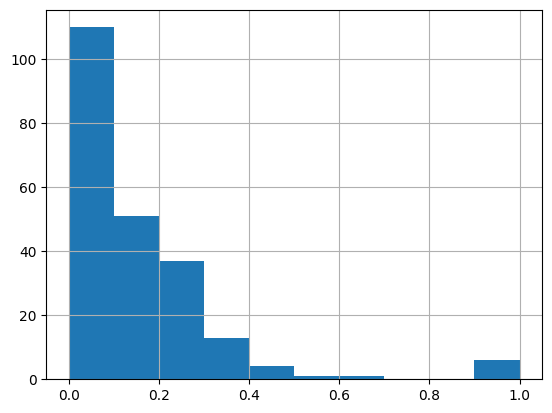

In [203]:
df_sponsors["passage_rate"].hist()

<Axes: >

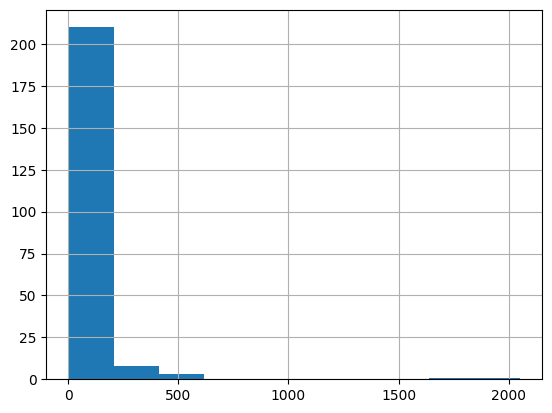

In [204]:
df_sponsors["num_bills_primary"].hist()

In [209]:
df_sponsors["bills_introduced_percentile"] = df_sponsors["num_bills_primary"].rank(pct=True)

In [210]:
df_sponsors["passage_rate_percentile"] = df_sponsors["passage_rate"].rank(pct=True)

In [211]:
df_sponsors["average_percentile"] = (df_sponsors["bills_introduced_percentile"] + df_sponsors["passage_rate_percentile"]) / 2

In [215]:
df_sponsors.sort_values("average_percentile", ascending=False).head(20)

,passage_rate,num_bills_primary,name,donation_count_all,donation_count_L3,total_all,total_L3,pct_c_above_all,pct_c_above_L3,pct_$_above_all,...,amt_IL_L3,pct_c_IL_all,pct_c_IL_L3,pct_$_IL_all,pct_$_IL_L3,yrs_since_first,yrs_since_last,bills_introduced_percentile,passage_rate_percentile,average_percentile
3,0.370861,151,Adriane Johnson,732.0,448.0,661985.36,427307.57,0.121585,0.145089,0.501488,...,374956.91,0.855191,0.828125,0.862835,0.877487,6.0,0.0,0.896861,0.941704,0.919283
16,0.317647,170,Bill Cunningham,2745.0,787.0,4376271.98,1703534.90,0.304918,0.494282,0.744100,...,1117381.96,0.750820,0.649301,0.749466,0.655920,16.0,0.0,0.919283,0.901345,0.910314
34,0.430769,130,Christopher Belt,1519.0,658.0,5732952.06,1494823.24,0.275839,0.273556,0.886156,...,1140347.41,0.778144,0.743161,0.893673,0.762864,9.0,0.0,0.860987,0.950673,0.905830
29,0.265823,158,Celina Villanueva,866.0,387.0,1139025.52,387327.74,0.176674,0.167959,0.693612,...,313705.48,0.814088,0.733850,0.907777,0.809923,8.0,1.0,0.912556,0.856502,0.884529
19,0.462963,108,Bob Morgan,1937.0,634.0,1820339.81,794053.75,0.127517,0.194006,0.538876,...,661803.75,0.885906,0.826498,0.878523,0.833450,9.0,0.0,0.809417,0.959641,0.884529
53,0.341085,129,David Koehler,3044.0,422.0,6898756.66,1084878.42,0.312746,0.507109,0.840529,...,921304.01,0.849540,0.767773,0.877753,0.849223,21.0,1.0,0.856502,0.910314,0.883408
129,0.255682,176,Laura Fine,2094.0,335.0,1798628.29,355965.06,0.134670,0.179104,0.515527,...,323179.11,0.868672,0.853731,0.889573,0.907896,14.0,0.0,0.928251,0.829596,0.878924
66,0.297710,131,Doris Turner,1070.0,510.0,5313247.42,1215738.01,0.297196,0.272549,0.925648,...,1003611.03,0.888785,0.837255,0.926161,0.825516,22.0,0.0,0.867713,0.887892,0.877803
10,0.290076,131,Anna Moeller,1344.0,384.0,2531502.12,423701.44,0.203869,0.143229,0.776650,...,361666.71,0.832589,0.804688,0.777684,0.853589,12.0,1.0,0.867713,0.878924,0.873318
111,0.344828,116,Karina Villa,1764.0,723.0,6143881.03,1623313.64,0.252268,0.221300,0.898703,...,1495800.14,0.910998,0.917012,0.926350,0.921449,9.0,0.0,0.825112,0.919283,0.872197
